# Clasp weighted-sequence: adaptive-policy and fixed-depth incumbent analytics

This notebook compares the six adaptive RF-depth policies in `02_policies` with fixed RF depths 5, 10, 15, 20, and 30 from `01_initial_cw`. Lower PAR10 is better. Every displayed incumbent configuration is independently evaluated on all 240 training instances at fixed target quantile seed 0.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from IPython.display import display

HERE = Path.cwd().resolve()
if not (HERE / 'results').is_dir():
    HERE = (Path.cwd() / 'experiments/aclib/clasp_weighted-sequence_surrogate/02_policies').resolve()
ACLIB_ROOT = HERE.parents[1]
if str(ACLIB_ROOT) not in sys.path:
    sys.path.insert(0, str(ACLIB_ROOT))

from policy_analytics import (
    build_policy_comparison,
    plot_common_horizon_incumbents,
    plot_incumbent_trajectories,
    plot_observed_endpoint_incumbents,
)

BENCHMARK_KEY = 'clasp_weighted'
INITIAL_DIRECTORY = HERE.parent / '01_initial_cw'
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': False})
print('Policy experiment:', HERE)
print('Fixed-depth experiment:', INITIAL_DIRECTORY)

Policy experiment: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/clasp_weighted-sequence_surrogate/02_policies
Fixed-depth experiment: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/clasp_weighted-sequence_surrogate/01_initial_cw


## Data loading, validation, and interruption coverage

Table: persistence status and observed trial count for every adaptive policy and SMAC seed. The cluster-wide `SIGBUS` interruption left some `runhistory.json` or `intensifier.json` files zero-filled/truncated. Exact trajectories are shown only when both artifacts are readable. The fixed-depth runs are complete at 5,000 trials. Adaptive runs are partial, and their lines stop at the last safely persisted trial.

In [2]:
comparison = build_policy_comparison(
    HERE,
    BENCHMARK_KEY,
    INITIAL_DIRECTORY,
)
display(
    comparison.availability.pivot(
        index='policy', columns='smac_seed', values='trajectory_status'
    )
)
display(
    comparison.availability.pivot(
        index='policy', columns='smac_seed', values='observed_trials'
    )
)
print('Full-training validation cache:', comparison.validation_cache_file)

Validation cache hit: 32 configurations from /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/clasp_weighted-sequence_surrogate/02_policies/analytics_cache/full_training_validation_qseed_0.json.


smac_seed,0,1,2
policy,,,
Error/variance trend,recoverable partial run,recoverable partial run,trajectory unavailable
Oracle depth schedule,trajectory unavailable,trajectory unavailable,trajectory unavailable
Rotating saturation k=50,trajectory unavailable,recoverable partial run,recoverable partial run
Saturation k=100,recoverable partial run,recoverable partial run,trajectory unavailable
Saturation k=250,recoverable partial run,recoverable partial run,recoverable partial run
Saturation k=50,recoverable partial run,trajectory unavailable,recoverable partial run


smac_seed,0,1,2
policy,,,
Error/variance trend,3945,3349,2977
Oracle depth schedule,4238,3511,3701
Rotating saturation k=50,4149,4463,3710
Saturation k=100,4336,3370,4541
Saturation k=250,4115,3455,3716
Saturation k=50,4134,3844,3837


Full-training validation cache: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/clasp_weighted-sequence_surrogate/02_policies/analytics_cache/full_training_validation_qseed_0.json


## Incumbent value versus SMAC trial

Step plots: one figure per SMAC seed comparing adaptive policies (solid colored lines) with fixed depths (dashed gray lines). Each height is the current SMAC incumbent re-evaluated on every training instance at quantile seed 0. An `×` marks a partial adaptive run's last persisted point. The second set repeats the comparison on a logarithmic PAR10 axis.

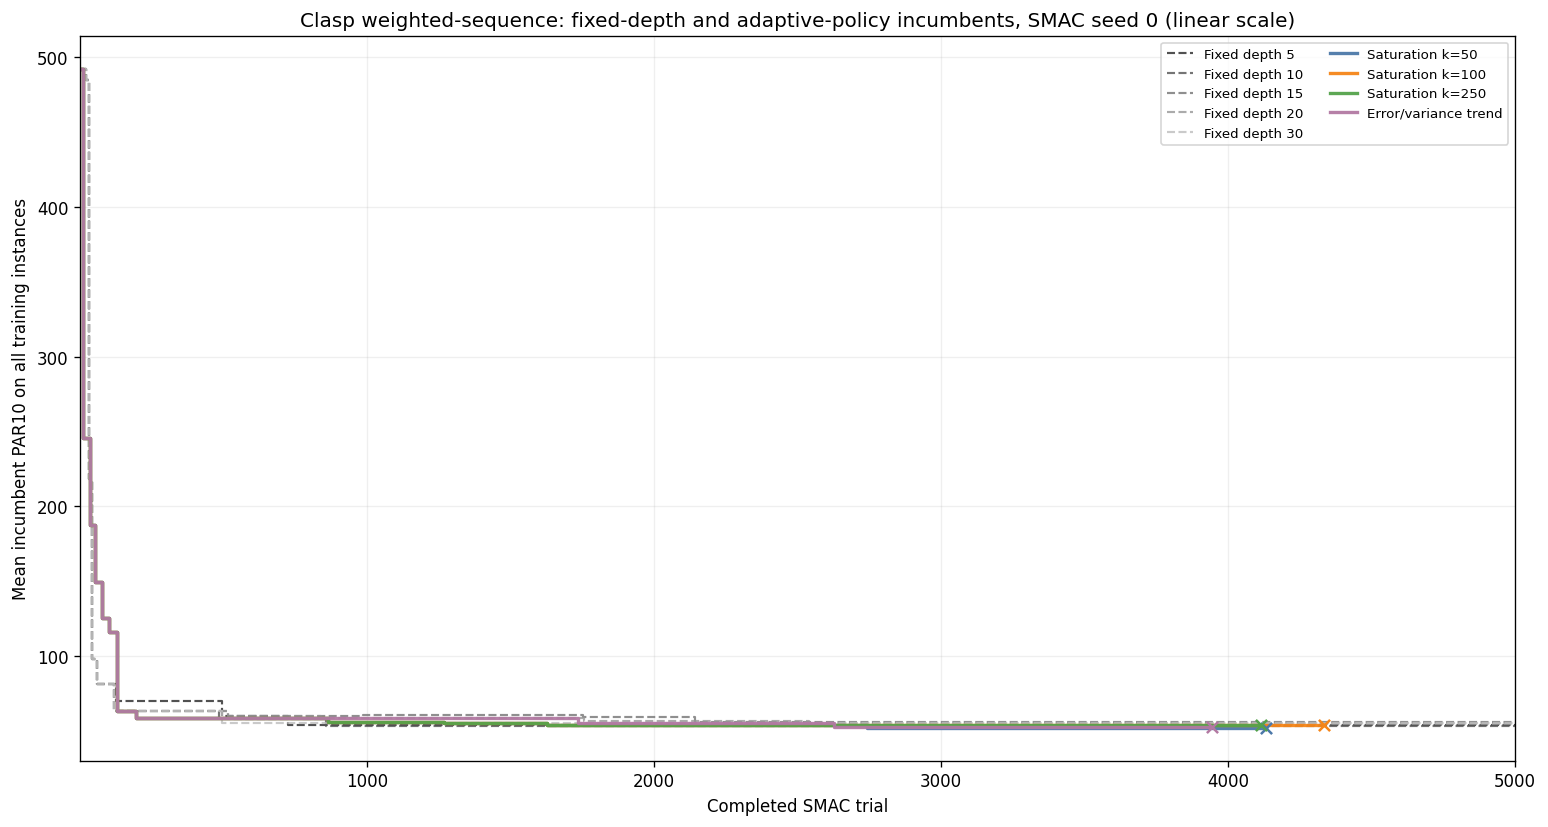

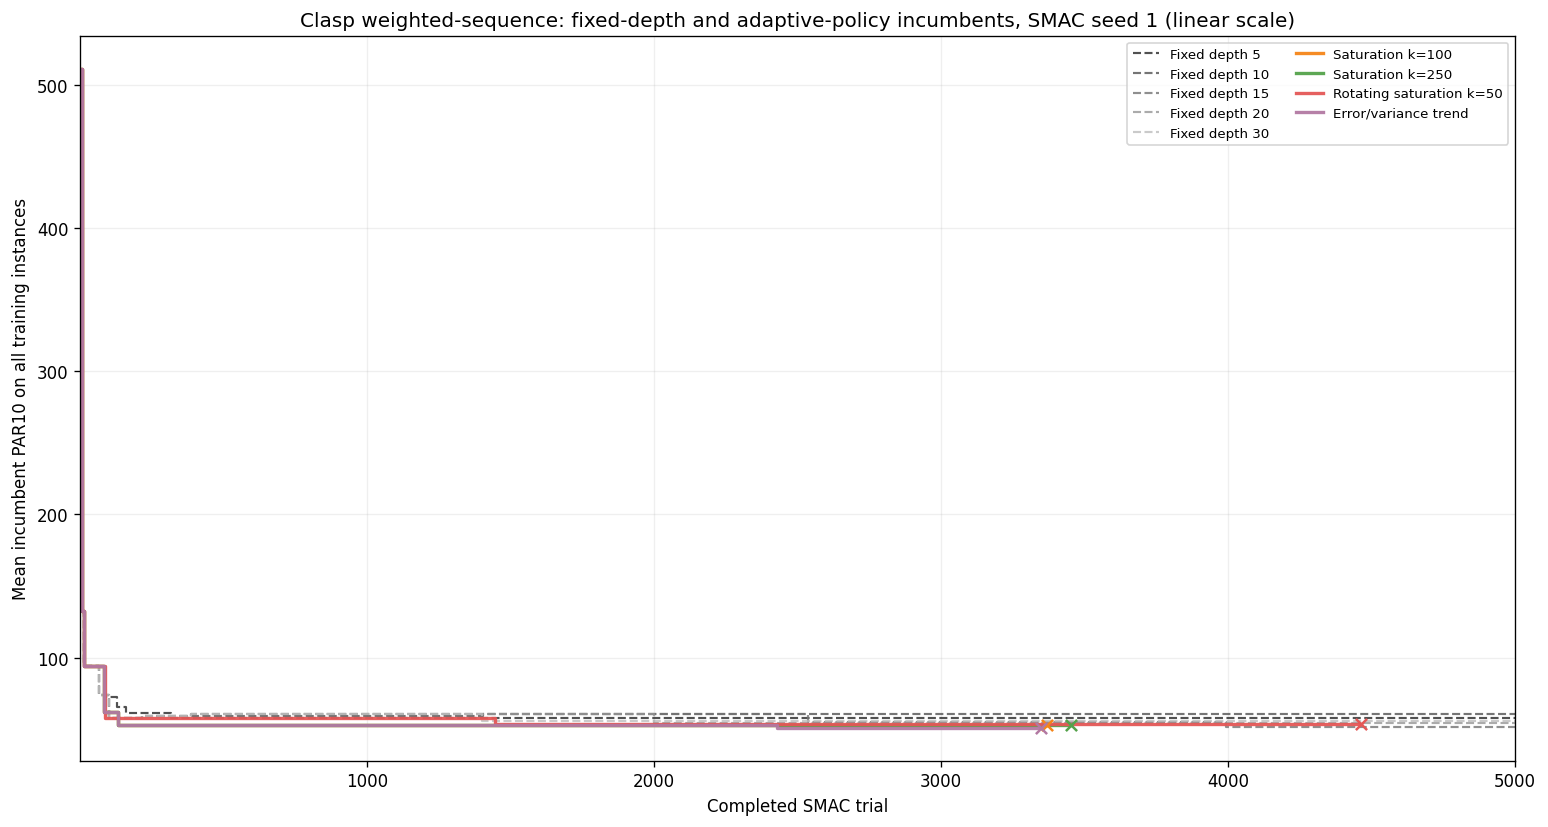

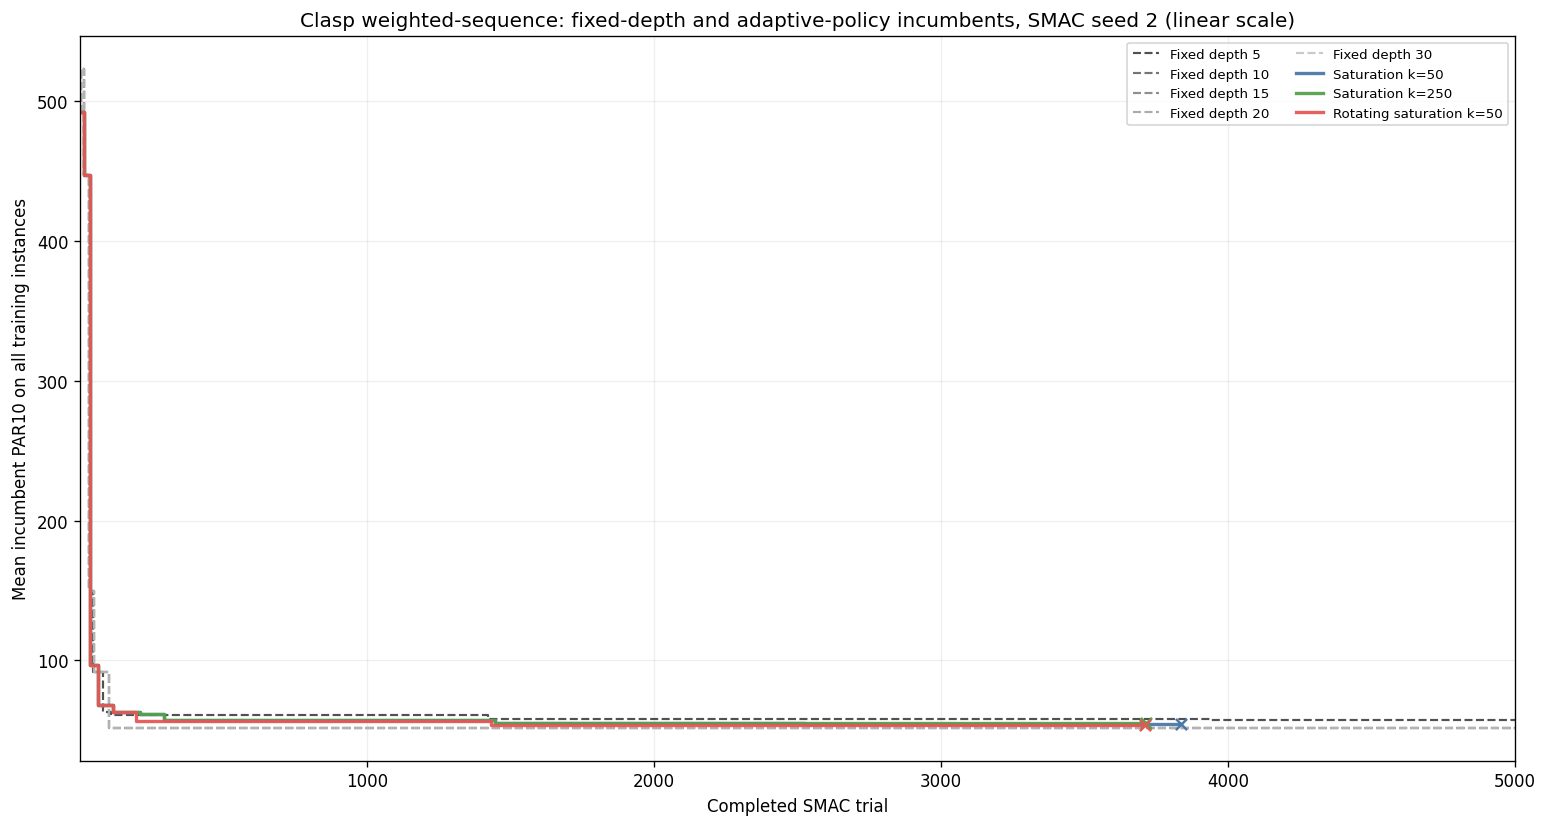

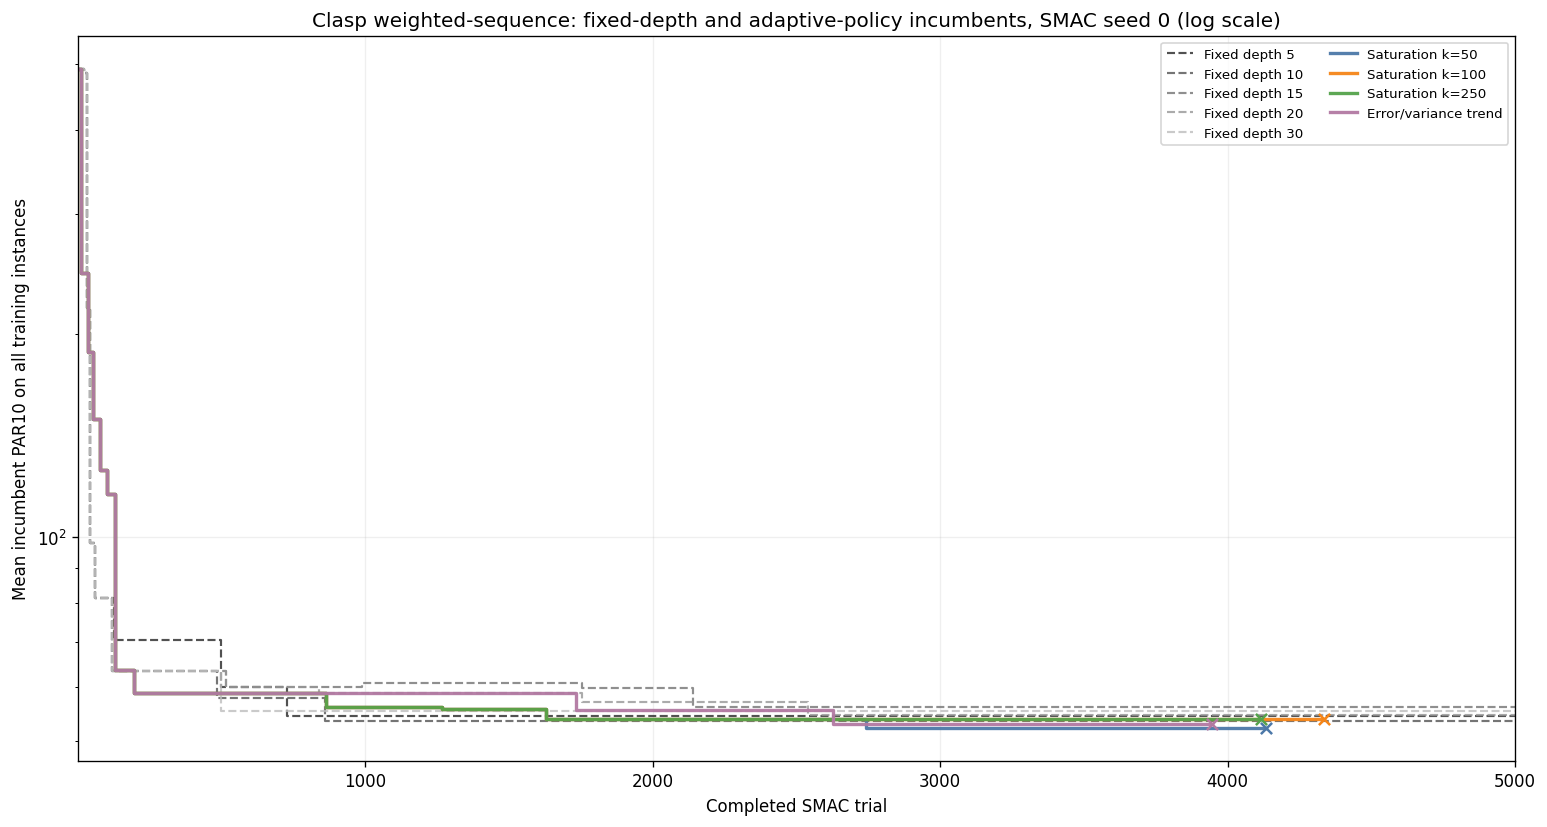

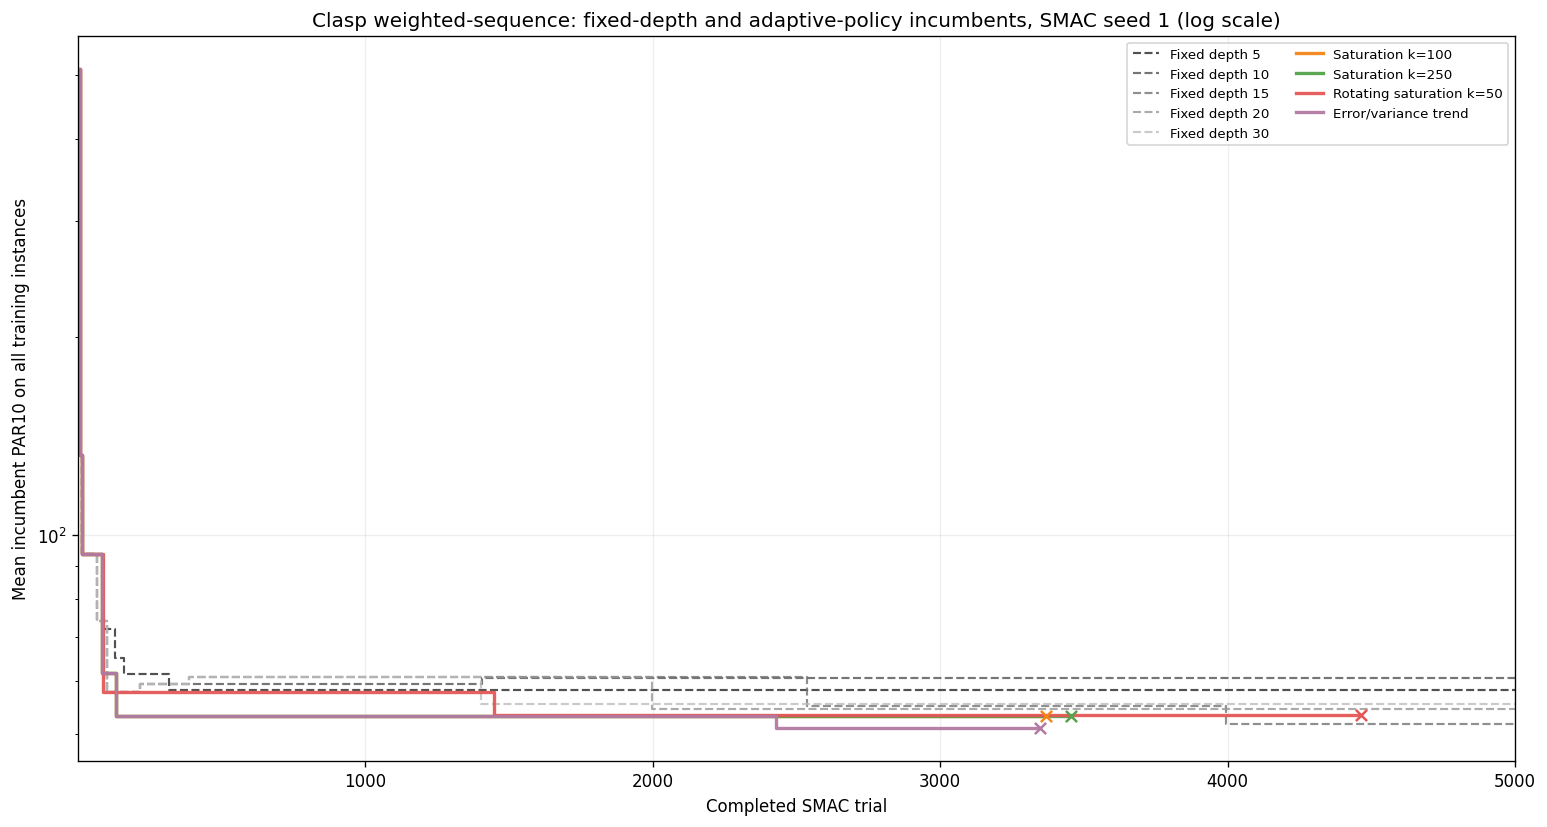

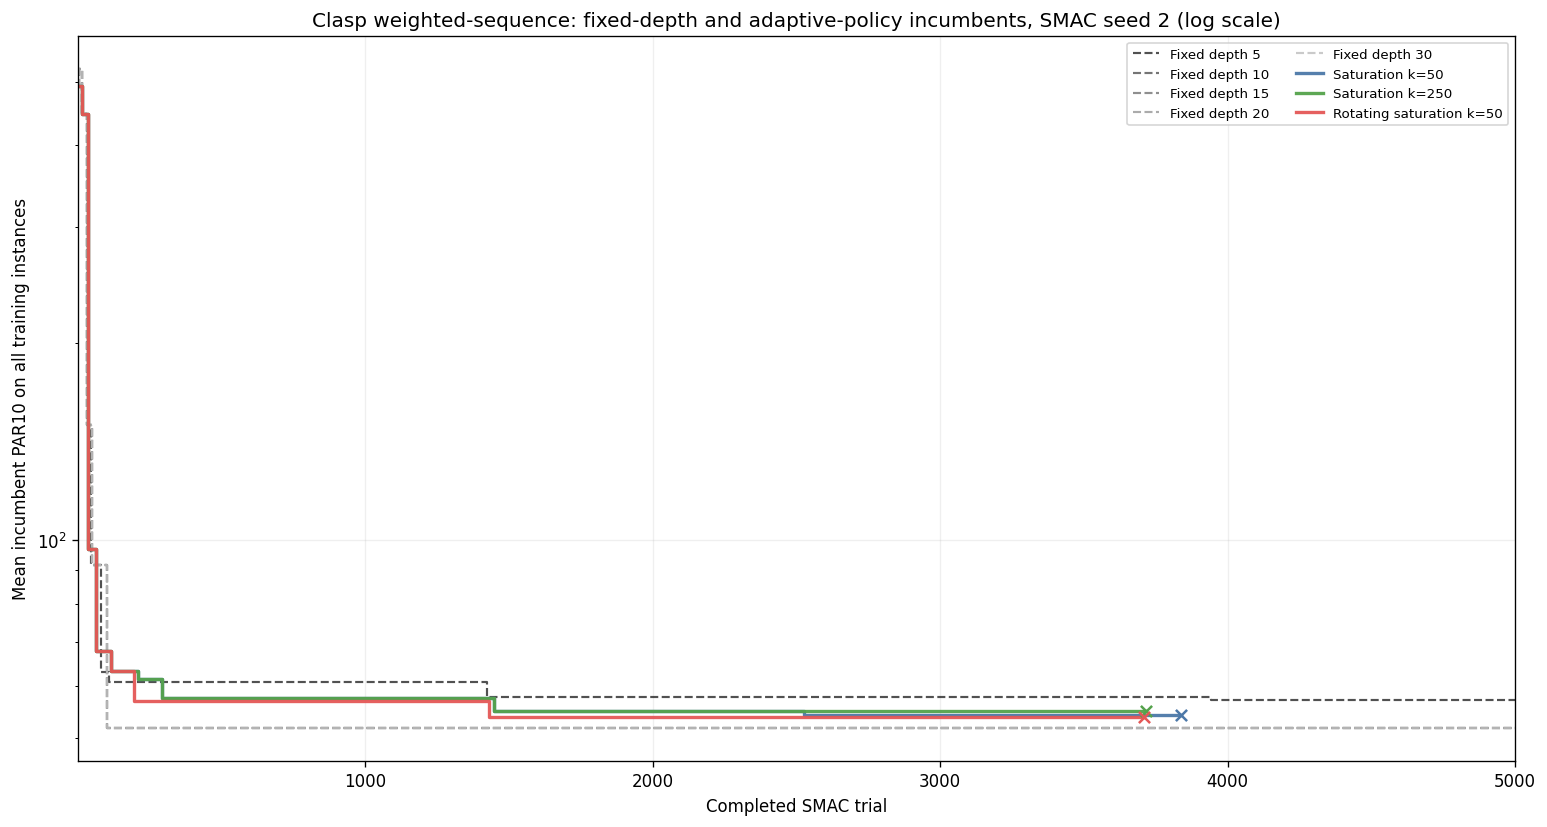

In [3]:
plot_incumbent_trajectories(comparison)
plt.show()

plot_incumbent_trajectories(comparison, logarithmic=True)
plt.show()

## Final observed incumbent by SMAC seed and policy

Horizontal bar charts: independently validated incumbent PAR10 at each run's last persisted trial. Fixed-depth values are true 5,000-trial finals; adaptive-policy values are interrupted endpoints at different trial counts and must not be interpreted as 5,000-trial finals. The table includes each endpoint trial explicitly.

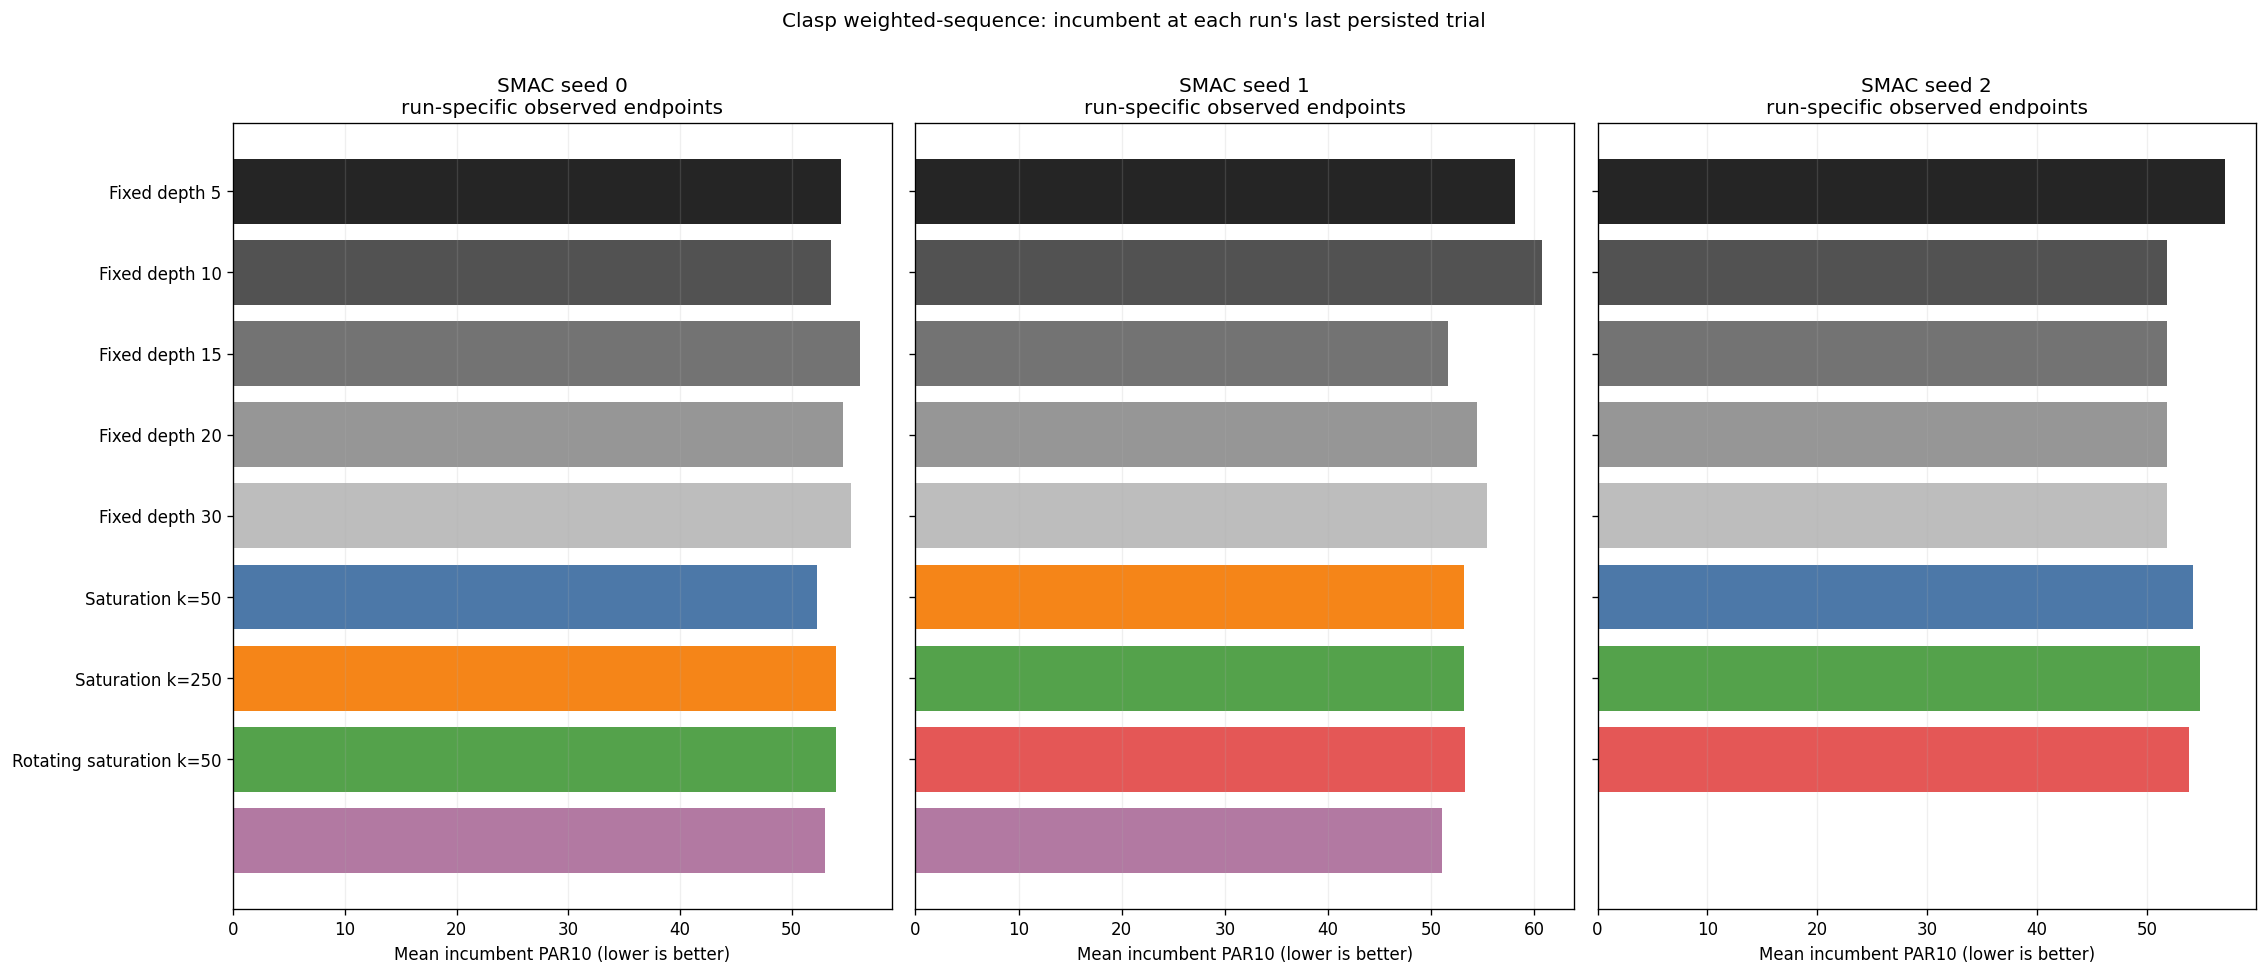

family  trial  \
smac_seed method                                             
0         Fixed depth 5                 fixed depth   5000   
          Fixed depth 10                fixed depth   5000   
          Fixed depth 15                fixed depth   5000   
          Fixed depth 20                fixed depth   5000   
          Fixed depth 30                fixed depth   5000   
          Saturation k=50           adaptive policy   4134   
          Saturation k=100          adaptive policy   4336   
          Saturation k=250          adaptive policy   4115   
          Error/variance trend      adaptive policy   3945   
1         Fixed depth 5                 fixed depth   5000   
          Fixed depth 10                fixed depth   5000   
          Fixed depth 15                fixed depth   5000   
          Fixed depth 20                fixed depth   5000   
          Fixed depth 30                fixed depth   5000   
          Saturation k=100          adaptive policy   3370   
          Saturation k=250          adaptive policy   3455   
          Rotating saturation k=50  adaptive policy   4463   
          Error/variance trend      adaptive policy   3349   
2         Fixed depth 5                 fixed depth   5000   
          Fixed depth 10                fixed depth   5000   
          Fixed depth 15                fixed depth   5000   
          Fixed depth 20                fixed depth   5000   
          Fixed depth 30                fixed depth   5000   
          Saturation k=50           adaptive policy   3837   
          Saturation k=250          adaptive policy   3716   
          Rotating saturation k=50  adaptive policy   3710   

                                    full_training_par10  config_id  \
smac_seed method                                                     
0         Fixed depth 5                       54.459027        144   
          Fixed depth 10                      53.501396        191   
          Fixed depth 15                      56.140493        340   
          Fixed depth 20                      54.588599        487   
          Fixed depth 30                      55.316467        105   
          Saturation k=50                     52.306865        810   
          Saturation k=100                    53.973807        377   
          Saturation k=250                    53.973807        377   
          Error/variance trend                52.947632        709   
1         Fixed depth 5                       58.154023         65   
          Fixed depth 10                      60.800296        284   
          Fixed depth 15                      51.627438        739   
          Fixed depth 20                      54.484682        423   
          Fixed depth 30                      55.428302        304   
          Saturation k=100                    53.150137         30   
          Saturation k=250                    53.150137         30   
          Rotating saturation k=50            53.304365        248   
          Error/variance trend                51.034972        801   
2         Fixed depth 5                       57.087166        797   
          Fixed depth 10                      51.802235         26   
          Fixed depth 15                      51.802235         26   
          Fixed depth 20                      51.802235         26   
          Fixed depth 30                      51.802235         26   
          Saturation k=50                     54.207298        949   
          Saturation k=250                    54.850616        395   
          Rotating saturation k=50            53.831948        443   

                                    run_complete  
smac_seed method                                  
0         Fixed depth 5                     True  
          Fixed depth 10                    True  
          Fixed depth 15                    True  
          Fixed depth 20                    True  
          Fixed depth 30                 

In [4]:
plot_observed_endpoint_incumbents(comparison)
plt.show()

endpoint_table = comparison.endpoints[[
    'smac_seed', 'method', 'family', 'trial',
    'full_training_par10', 'config_id', 'run_complete'
]].copy()
display(endpoint_table.set_index(['smac_seed', 'method']))

## Fair comparison at a common observed horizon

Horizontal bar charts: for each SMAC seed, all recoverable methods are compared at the minimum persisted endpoint among that seed's recoverable adaptive runs. This removes the unequal-horizon bias in the endpoint chart. Policies with corrupted trajectory artifacts remain absent rather than being reconstructed approximately.

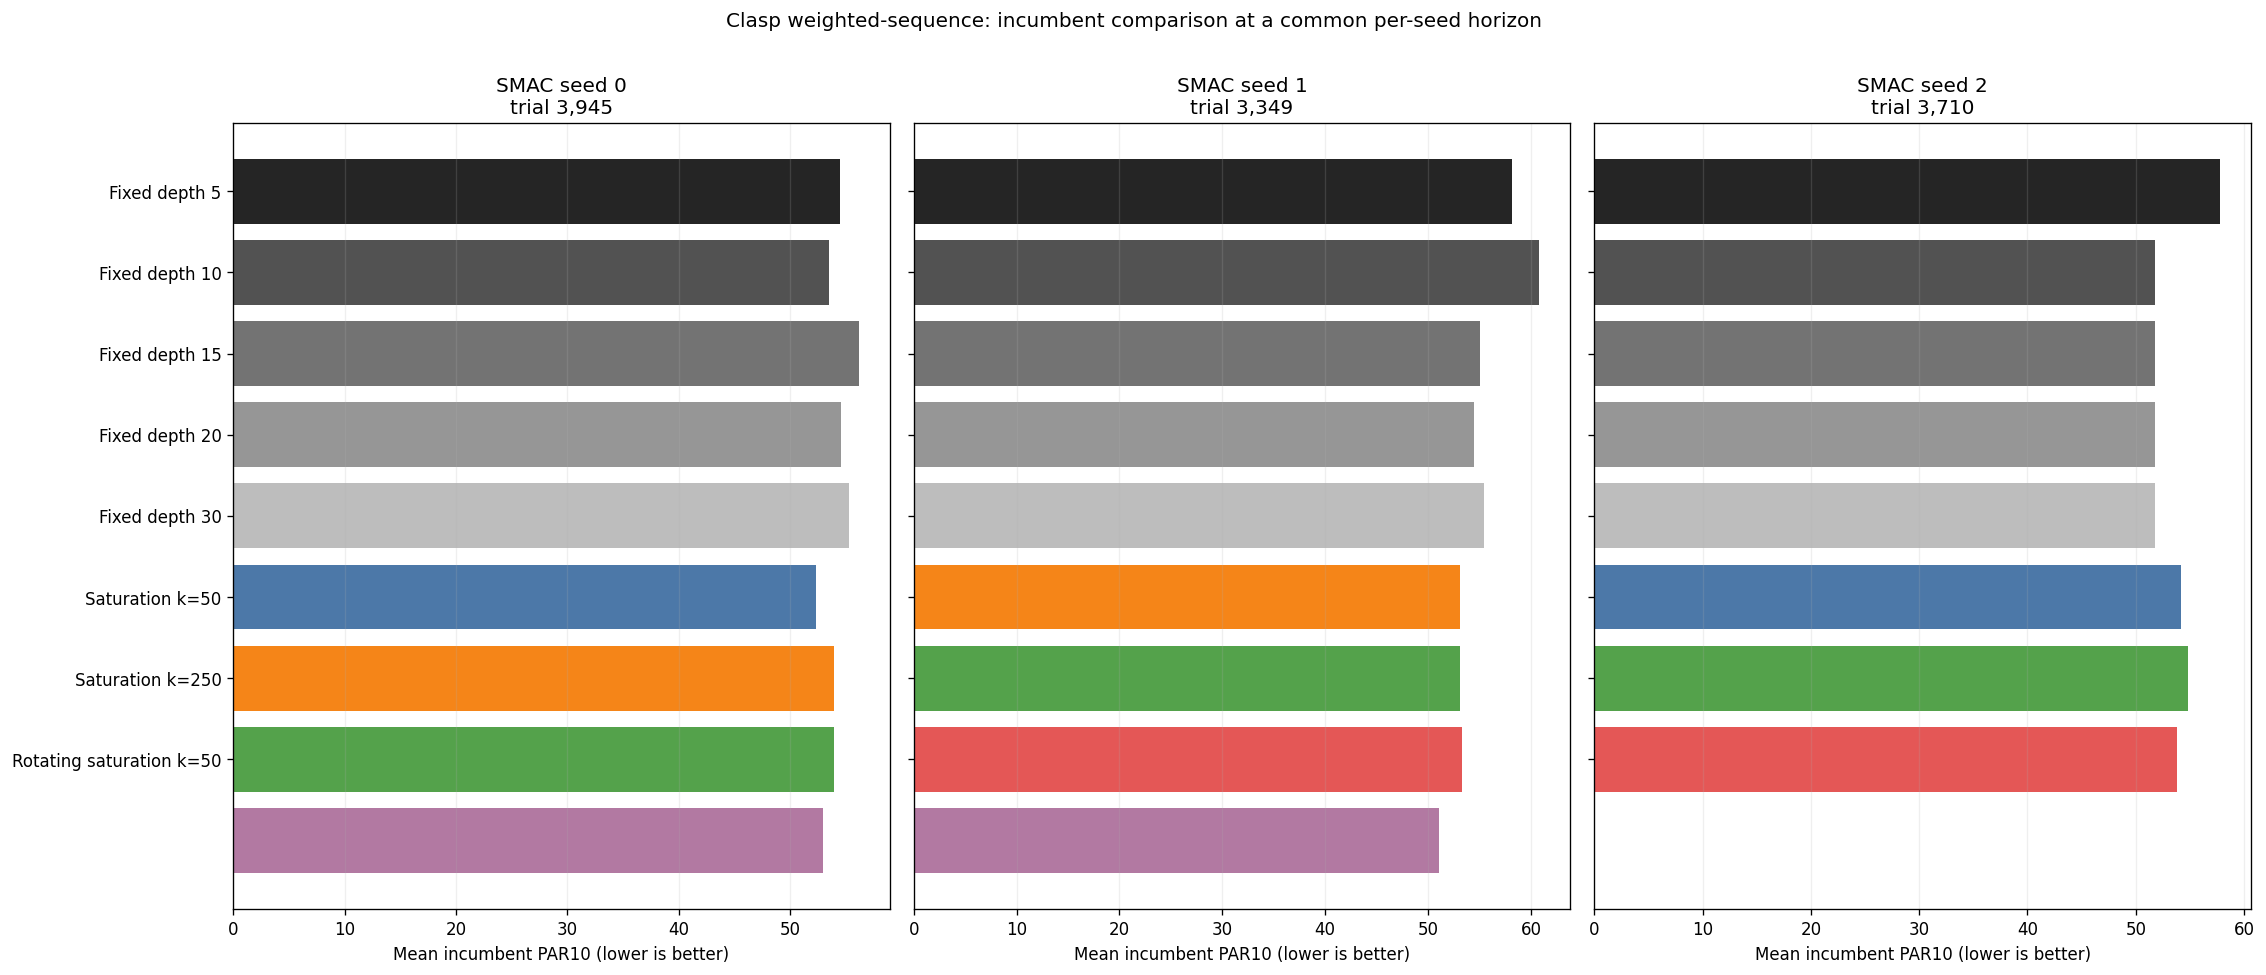

family  \
smac_seed common_trial method                                      
0         3945         Fixed depth 5                 fixed depth   
                       Fixed depth 10                fixed depth   
                       Fixed depth 15                fixed depth   
                       Fixed depth 20                fixed depth   
                       Fixed depth 30                fixed depth   
                       Saturation k=50           adaptive policy   
                       Saturation k=100          adaptive policy   
                       Saturation k=250          adaptive policy   
                       Error/variance trend      adaptive policy   
1         3349         Fixed depth 5                 fixed depth   
                       Fixed depth 10                fixed depth   
                       Fixed depth 15                fixed depth   
                       Fixed depth 20                fixed depth   
                       Fixed depth 30                fixed depth   
                       Saturation k=100          adaptive policy   
                       Saturation k=250          adaptive policy   
                       Rotating saturation k=50  adaptive policy   
                       Error/variance trend      adaptive policy   
2         3710         Fixed depth 5                 fixed depth   
                       Fixed depth 10                fixed depth   
                       Fixed depth 15                fixed depth   
                       Fixed depth 20                fixed depth   
                       Fixed depth 30                fixed depth   
                       Saturation k=50           adaptive policy   
                       Saturation k=250          adaptive policy   
                       Rotating saturation k=50  adaptive policy   

                                                 full_training_par10  
smac_seed common_trial method                                         
0         3945         Fixed depth 5                       54.459027  
                       Fixed depth 10                      53.501396  
                       Fixed depth 15                      56.140493  
                       Fixed depth 20                      54.588599  
                       Fixed depth 30                      55.316467  
                       Saturation k=50                     52.306865  
                       Saturation k=100                    53.973807  
                       Saturation k=250                    53.973807  
                       Error/variance trend                52.947632  
1         3349         Fixed depth 5                       58.154023  
                       Fixed depth 10                      60.800296  
                       Fixed depth 15                      55.087579  
                       Fixed depth 20                      54.484682  
                       Fixed depth 30                      55.428302  
                       Saturation k=100                    53.150137  
                       Saturation k=250                    53.150137  
                       Rotating saturation k=50            53.304365  
                       Error/variance trend                51.034972  
2         3710         Fixed depth 5                       57.749148  
                       Fixed depth 10                      51.802235  
                       Fixed depth 15                      51.802235  
                       Fixed depth 20                      51.802235  
                       Fixed depth 30                      51.802235  
                       Saturation k=50                     54.207298  
                       Saturation k=250                    54.850616  
                       Rotating saturation k=50            53.831948

In [5]:
plot_common_horizon_incumbents(comparison)
plt.show()
display(
    comparison.common_horizon.set_index(
        ['smac_seed', 'common_trial', 'method']
    )
)